In [1]:
import gtsam
import matplotlib.pyplot as plt
import numpy as np
from gtsam import symbol_shorthand
L = symbol_shorthand.L
X = symbol_shorthand.X

from gtsam.examples import SFMdata
from gtsam import (Cal3_S2, DoglegOptimizer,
                         GenericProjectionFactorCal3_S2, Marginals,
                         NonlinearFactorGraph, PinholeCameraCal3_S2, Point3,
                         Pose3, PriorFactorPoint3, PriorFactorPose3, Rot3, Values)
from gtsam.utils import plot
%matplotlib inline

In [3]:
# Define the camera calibration parameters
K = Cal3_S2(50.0, 50.0, 0.0, 50.0, 50.0)

# Define the camera observation noise model
measurement_noise = gtsam.noiseModel.Isotropic.Sigma(
    2, 1.0)  # one pixel in u and v

# Create the set of ground-truth landmarks
points = SFMdata.createPoints()

# Create the set of ground-truth poses
poses = SFMdata.createPoses()

In [4]:
# Create a factor graph
graph = NonlinearFactorGraph()

# Add a prior on pose x1. This indirectly specifies where the origin is.
# 0.3 rad std on roll,pitch,yaw and 0.1m on x,y,z
pose_noise = gtsam.noiseModel.Diagonal.Sigmas(
     np.array([0.3, 0.3, 0.3, 0.1, 0.1, 0.1]))
factor = PriorFactorPose3(X(0), poses[0], pose_noise)
graph.push_back(factor)

# Simulated measurements from each camera pose, adding them to the factor graph
for i, pose in enumerate(poses):
    camera = PinholeCameraCal3_S2(pose, K)
    for j, point in enumerate(points):
        measurement = camera.project(point)
        factor = GenericProjectionFactorCal3_S2(
            measurement, measurement_noise, X(i), L(j), K)
        graph.push_back(factor)

In [5]:
point_noise = gtsam.noiseModel.Isotropic.Sigma(3, 0.1)
factor = PriorFactorPoint3(L(0), points[0], point_noise)
graph.push_back(factor)
graph.print('Factor Graph:\n')

Factor Graph:
size: 66

Factor 0: PriorFactor on x0
  prior mean:  R: [
	6.12323e-17, -6.12323e-17, -1;
	1, 3.7494e-33, 6.12323e-17;
	-0, -1, 6.12323e-17
]
t: 30  0  0
  noise model: diagonal sigmas [0.3; 0.3; 0.3; 0.1; 0.1; 0.1];

Factor 1: GenericProjectionFactor, z = [
	75;
	25
]
  keys = { x0 l0 }
  noise model: unit (2) 

Factor 2: GenericProjectionFactor, z = [
	62.5;
	37.5
]
  keys = { x0 l1 }
  noise model: unit (2) 

Factor 3: GenericProjectionFactor, z = [
	37.5;
	37.5
]
  keys = { x0 l2 }
  noise model: unit (2) 

Factor 4: GenericProjectionFactor, z = [
	25;
	25
]
  keys = { x0 l3 }
  noise model: unit (2) 

Factor 5: GenericProjectionFactor, z = [
	75;
	75
]
  keys = { x0 l4 }
  noise model: unit (2) 

Factor 6: GenericProjectionFactor, z = [
	62.5;
	62.5
]
  keys = { x0 l5 }
  noise model: unit (2) 

Factor 7: GenericProjectionFactor, z = [
	37.5;
	62.5
]
  keys = { x0 l6 }
  noise model: unit (2) 

Factor 8: GenericProjectionFactor, z = [
	25;
	75
]
  keys = { x0 l7 }
  

In [7]:
initial_estimate = Values()
for i, pose in enumerate(poses):
    transformed_pose = pose.retract(0.1*np.random.randn(6, 1))
    initial_estimate.insert(X(i), transformed_pose)
for j, point in enumerate(points):
    transformed_point = point + 0.1*np.random.randn(3)
    initial_estimate.insert(L(j), transformed_point)
initial_estimate.print('Initial Estimates:\n')

Initial Estimates:

Values with 16 values:
Value l0: (Eigen::Matrix<double, -1, 1, 0, -1, 1>)
[
	10.113587;
	10.058493;
	10.1846443
]

Value l1: (Eigen::Matrix<double, -1, 1, 0, -1, 1>)
[
	-10.0349169;
	10.0384628;
	10.0105575
]

Value l2: (Eigen::Matrix<double, -1, 1, 0, -1, 1>)
[
	-9.96814392;
	-9.94700615;
	10.072064
]

Value l3: (Eigen::Matrix<double, -1, 1, 0, -1, 1>)
[
	10.0007489;
	-9.95782637;
	10.1224864
]

Value l4: (Eigen::Matrix<double, -1, 1, 0, -1, 1>)
[
	9.81876241;
	9.91961926;
	-9.92432407
]

Value l5: (Eigen::Matrix<double, -1, 1, 0, -1, 1>)
[
	-10.0622721;
	9.8817142;
	-9.97297669
]

Value l6: (Eigen::Matrix<double, -1, 1, 0, -1, 1>)
[
	-9.95833145;
	-10.2325817;
	-9.90663154
]

Value l7: (Eigen::Matrix<double, -1, 1, 0, -1, 1>)
[
	9.9734953;
	-10.0371695;
	-9.90379807
]

Value x0: (gtsam::Pose3)
R: [
	-0.0575080985, 0.0206822995, -0.998130784;
	0.998342027, -0.00126495537, -0.0575464806;
	-0.00245278444, -0.999785298, -0.0205752636
]
t:    30.0202231 0.00664088542 0

In [8]:
params = gtsam.DoglegParams()
params.setVerbosity('TERMINATION')
optimizer = DoglegOptimizer(graph, initial_estimate, params)
print('Optimizing:')
result = optimizer.optimize()
result.print('Final results:\n')
print('initial error = {}'.format(graph.error(initial_estimate)))
print('final error = {}'.format(graph.error(result)))

Optimizing:
Final results:

Values with 16 values:
Value l0: (Eigen::Matrix<double, -1, 1, 0, -1, 1>)
[
	10;
	10;
	10
]
converged
errorThreshold: 3.92897476e-22 <? 0
absoluteDecrease: 1.42708281565e-09 <? 1e-05
relativeDecrease: 1 <? 1e-05
iterations: 4 >? 100

Value l1: (Eigen::Matrix<double, -1, 1, 0, -1, 1>)
[
	-10;
	10;
	10
]

Value l2: (Eigen::Matrix<double, -1, 1, 0, -1, 1>)
[
	-10;
	-10;
	10
]

Value l3: (Eigen::Matrix<double, -1, 1, 0, -1, 1>)
[
	10;
	-10;
	10
]

Value l4: (Eigen::Matrix<double, -1, 1, 0, -1, 1>)
[
	10;
	10;
	-10
]

Value l5: (Eigen::Matrix<double, -1, 1, 0, -1, 1>)
[
	-10;
	10;
	-10
]

Value l6: (Eigen::Matrix<double, -1, 1, 0, -1, 1>)
[
	-10;
	-10;
	-10
]

Value l7: (Eigen::Matrix<double, -1, 1, 0, -1, 1>)
[
	10;
	-10;
	-10
]

Value x0: (gtsam::Pose3)
R: [
	1.14976460506e-15, -3.83209464537e-15, -1;
	1, 1.34116768459e-15, 1.14939273293e-15;
	1.34080609389e-15, -1, 3.83000691164e-15
]
t:                30 1.54842199313e-18 1.64457743622e-17

Value x1: (gtsam::

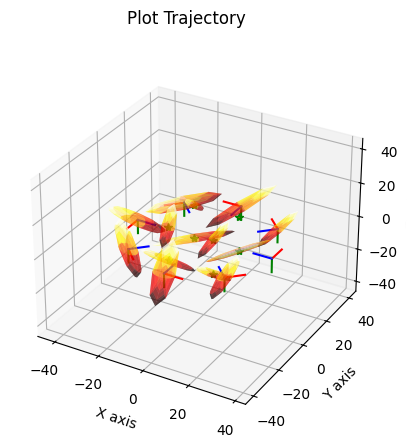

In [9]:
marginals = Marginals(graph, result)
plot.plot_3d_points(1, result, marginals=marginals)
plot.plot_trajectory(1, result, marginals=marginals, scale=8)
plot.set_axes_equal(1)
plt.show()